## txt转excel

In [6]:
with open("train_dict.txt",encoding="utf8") as f:
    texts = f.readlines()
data=[]
for i in texts:
    data.append(eval(i))
data

[{'title': '恒瑞医药注射用卡瑞利珠单抗主要研究终点结果达到方案预设优效标准', 'label': '1'},
 {'title': '中集集团建议分拆中集安瑞环科并独立于股上市', 'label': '1'},
 {'title': '郑中设计非公开发行股票申请获得证监会核准批复', 'label': '1'},
 {'title': '泽璟制药公司在研产品获得美国孤儿药资格认定', 'label': '1'},
 {'title': '海思科创新药乳状注射液获药物临床试验批准', 'label': '1'},
 {'title': '九阳股份子公司部分土地将被收储补偿金额约亿元', 'label': '1'},
 {'title': '特发信息子公司与特殊机构客户签订亿元军品采购框架协议', 'label': '1'},
 {'title': '通鼎互联预中标中国电信集中采购项目', 'label': '1'},
 {'title': '美联新材拟收购成都菲斯特新材料有限公司股权', 'label': '1'},
 {'title': '微芯生物与海正药业签署独占许可及联合营销战略合作协议', 'label': '1'},
 {'title': '广州发展控股子公司拟投建二期项目总投资约亿元', 'label': '1'},
 {'title': '一汽富维中国一汽关联方通过大宗交易增持公司股份', 'label': '1'},
 {'title': '深康佳拟出资不超亿元参与设立重庆康芯半导体产业基金', 'label': '1'},
 {'title': '名家汇拟发行股份收购爱特微张家港半导体技术有限公司股权股票停牌', 'label': '1'},
 {'title': '中国天楹筹划分拆全资子公司江苏城环至创业板上市', 'label': '1'},
 {'title': '国投电力长江电力及其一致行动人增持公司股份合计持股比例升至', 'label': '1'},
 {'title': '红墙股份预计全年盈利亿元至亿元同比增长至', 'label': '1'},
 {'title': '中国中冶前月新签合同额亿元同比增长', 'label': '1'},
 {'title': '招商港口月集装箱业务完成吞吐量同比增长', 'label': 

## 数据集处理与切分

In [9]:
import json
import pandas as pd
import random

# 示例数据


# 打乱数据顺序
random.shuffle(data)

# 按8:2比例拆分数据
split_index = int(0.8 * len(data))
train_data = data[:split_index]
test_data = data[split_index:]

# 创建DataFrame
train_df = pd.DataFrame(train_data, columns=['title', 'label'])
test_df = pd.DataFrame(test_data, columns=['title', 'label'])

# 重命名列
train_df.columns = ['comment', 'sentiment']
test_df.columns = ['comment', 'sentiment']

# 保存到Excel文件
with pd.ExcelWriter('train_test_data.xlsx') as writer:
    train_df.to_excel(writer, sheet_name='train')
    test_df.to_excel(writer, sheet_name='test')

print("数据已成功保存到 train_test_data.xlsx 文件中。")

C:\Users\h1516\AppData\Local\Temp\ipykernel_28072\454768734.py:25: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  with pd.ExcelWriter('train_test_data.xlsx') as writer:


数据已成功保存到 train_test_data.xlsx 文件中。


## 数据展示

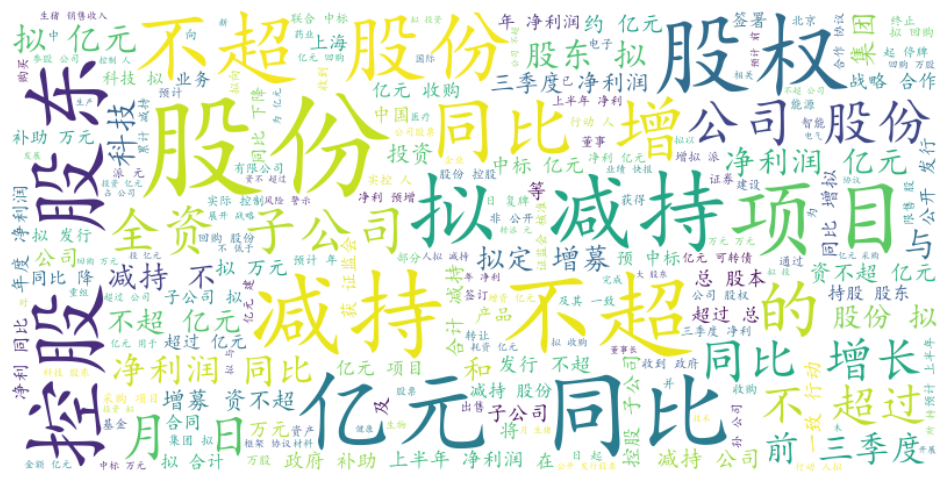

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import jieba
df=pd.read_excel("train_test_data.xlsx")
# 请将以下数据替换为你的实际数据
df1=df['comment']

font_path = 'simkai.ttf'
# 将"(空)"值替换为NaN，并去除包含NaN的行


text = ' '.join(df1)
# 使用jieba进行分词
seg_list = jieba.cut(text, cut_all=False)
seg_str = ' '.join(seg_list)
wordcloud = WordCloud(font_path=font_path,width=800, height=400, background_color='white').generate(seg_str)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## BERT模型构建

In [2]:
import time
import math
import numpy as np
import torch
from torch import nn
from tqdm import tqdm
from sklearn.metrics import classification_report
from concurrent.futures import ThreadPoolExecutor
from torch.utils.data import TensorDataset, DataLoader
from pytorch_pretrained_bert import BertTokenizer, BertModel
from pytorch_pretrained_bert.optimization import BertAdam
import matplotlib.pyplot as plt
import seaborn as sns

class ClassifyModel(nn.Module):
    def __init__(self, pretrained_model_name_or_path, num_labels, is_lock=False):
        super(ClassifyModel, self).__init__()
        self.bert = BertModel.from_pretrained(pretrained_model_name_or_path)
        config = self.bert.config
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(768, num_labels)
        if is_lock:
            # 加载并冻结bert模型参数
            for name, param in self.bert.named_parameters():
                if name.startswith('pooler'):
                    continue
                else:
                    param.requires_grad_(False)

    def forward(self, input_ids, token_type_ids=None, attention_mask=None):
        _, pooled = self.bert(input_ids, token_type_ids, attention_mask, output_all_encoded_layers=False)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        # 测试1，直接
        return logits


class DataProcessForSingleSentence(object):
    def __init__(self, bert_tokenizer, max_workers=10):
        """
        :param bert_tokenizer: 分词器
        :param max_workers:  包含列名comment和sentiment的data frame
        """
        self.bert_tokenizer = bert_tokenizer
        self.pool = ThreadPoolExecutor(max_workers=max_workers)

    def get_input(self, dataset, max_seq_len=30):
        sentences = dataset.iloc[:, 1].tolist()
        labels = dataset.iloc[:, 2].tolist()
        # 切词
        token_seq = list(self.pool.map(self.bert_tokenizer.tokenize, sentences))
        # 获取定长序列及其mask
        result = list(self.pool.map(self.trunate_and_pad, token_seq,
                                    [max_seq_len] * len(token_seq)))
        seqs = [i[0] for i in result]
        seq_masks = [i[1] for i in result]
        seq_segments = [i[2] for i in result]

        t_seqs = torch.tensor(seqs, dtype=torch.long)
        t_seq_masks = torch.tensor(seq_masks, dtype=torch.long)
        t_seq_segments = torch.tensor(seq_segments, dtype=torch.long)
        t_labels = torch.tensor(labels, dtype=torch.long)

        return TensorDataset(t_seqs, t_seq_masks, t_seq_segments, t_labels)

    def trunate_and_pad(self, seq, max_seq_len):
        # 对超长序列进行截断
        if len(seq) > (max_seq_len - 2):
            seq = seq[0: (max_seq_len - 2)]
            # 添加特殊字符
        seq = ['[CLS]'] + seq + ['[SEP]']
        # id化
        seq = self.bert_tokenizer.convert_tokens_to_ids(seq)
        # 根据max_seq_len与seq的长度产生填充序列
        padding = [0] * (max_seq_len - len(seq))
        # 创建seq_mask
        seq_mask = [1] * len(seq) + padding
        # 创建seq_segment
        seq_segment = [0] * len(seq) + padding
        # 对seq拼接填充序列
        seq += padding
        assert len(seq) == max_seq_len
        assert len(seq_mask) == max_seq_len
        assert len(seq_segment) == max_seq_len
        return seq, seq_mask, seq_segment


def load_data(filepath, pretrained_model_name_or_path, max_seq_len, batch_size):
    """
    加载excel文件，有train和test 的sheet
    :param filepath: 文件路径
    :param pretrained_model_name_or_path: 使用什么样的bert模型
    :param max_seq_len: bert最大尺寸，不能超过512
    :param batch_size: 小批量训练的数据
    :return: 返回训练和测试数据迭代器 DataLoader形式
    """
    io = pd.io.excel.ExcelFile(filepath)
    raw_train_data = pd.read_excel(io, sheet_name='train')
    raw_test_data = pd.read_excel(io, sheet_name='test')
    io.close()
    # 分词工具
    bert_tokenizer = BertTokenizer.from_pretrained(pretrained_model_name_or_path, do_lower_case=True)
    processor = DataProcessForSingleSentence(bert_tokenizer=bert_tokenizer)
    # 产生输入句 数据
    train_data = processor.get_input(raw_train_data, max_seq_len)
    test_data = processor.get_input(raw_test_data, max_seq_len)

    train_iter = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
    test_iter = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=True)
    # 训练和测试的样本数量
    total_train_batch = math.ceil(len(raw_train_data) / batch_size)
    total_test_batch = math.ceil(len(raw_test_data) / batch_size)
    return train_iter, test_iter, total_train_batch, total_test_batch


def evaluate_accuracy(data_iter, net, device, batch_count):
    # 记录预测标签和真实标签
    prediction_labels, true_labels = [], []
    with torch.no_grad():
        for batch_data in tqdm(data_iter, desc='eval', total=batch_count):
            batch_data = tuple(t.to(device) for t in batch_data)
            # 获取给定的输出和模型给的输出
            labels = batch_data[-1]
            output = net(*batch_data[:-1])
            predictions = output.softmax(dim=1).argmax(dim=1)
            prediction_labels.append(predictions.detach().cpu().numpy())
            true_labels.append(labels.detach().cpu().numpy())

    return classification_report(np.concatenate(true_labels), np.concatenate(prediction_labels))

# result_list=[]
# batch_size, max_seq_len = 512, 200
# train_iter, test_iter, train_batch_count, test_batch_count = load_data('train_test_data.xlsx', 'bert-base-chinese', max_seq_len, batch_size)
# # 加载模型
# # model = BertForSequenceClassification.from_pretrained('bert-base-chinese', num_labels=2)
# model = ClassifyModel('bert-base-chinese', num_labels=2, is_lock=True)
# print(model)

# optimizer = BertAdam(model.parameters(), lr=4e-05)
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model.to(device)
# loss_func = nn.CrossEntropyLoss()
# train_loss_history = []
# train_acc_history = []

# times=5
# for epoch in range(times):
#     start = time.time()
#     model.train()
#     # loss和精确度
#     train_loss_sum, train_acc_sum, n = 0.0, 0.0, 0
#     for step, batch_data in tqdm(enumerate(train_iter), desc='train epoch:{}/{}'.format(epoch + 1, times)
#                                 ,total=train_batch_count):
#         batch_data = tuple(t.to(device) for t in batch_data)
#         batch_seqs, batch_seq_masks, batch_seq_segments, batch_labels = batch_data

#         logits = model(batch_seqs, batch_seq_masks, batch_seq_segments)
#         loss = loss_func(logits, batch_labels)
#         loss.backward()
#         train_loss_sum += loss.item()
#         logits = logits.softmax(dim=1)
#         train_acc_sum += (logits.argmax(dim=1) == batch_labels).sum().item()
#         n += batch_labels.shape[0]
#         optimizer.step()
#         optimizer.zero_grad()
#     train_loss_history.append(train_loss_sum / n)
#     train_acc_history.append(train_acc_sum / n)
#     # 每一代都判断
#     model.eval()

#     result = evaluate_accuracy(test_iter, model, device,test_batch_count)
#     print('epoch %d, loss %.4f, train acc %.3f, time: %.3f' %
#           (epoch + 1, train_loss_sum / n, train_acc_sum / n, (time.time() - start)))

#     print(result)
#     result_list.append(result)
# sns.set(style="whitegrid")
# torch.save(model, 'fine_tuned_chinese_bert.bin')
# plt.figure(figsize=(12, 4))
# plt.subplot(1, 2, 1)
# plt.plot(range(1, times+1), train_loss_history, marker='o')
# plt.title('Testing Loss Over Epochs')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')

# plt.subplot(1, 2, 2)
# plt.plot(range(1, times+1), train_acc_history, marker='o')
# plt.title('Testing Accuracy Over Epochs')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')

# plt.tight_layout()
# plt.show()

## 数据可视化（在服务器训练的数据）

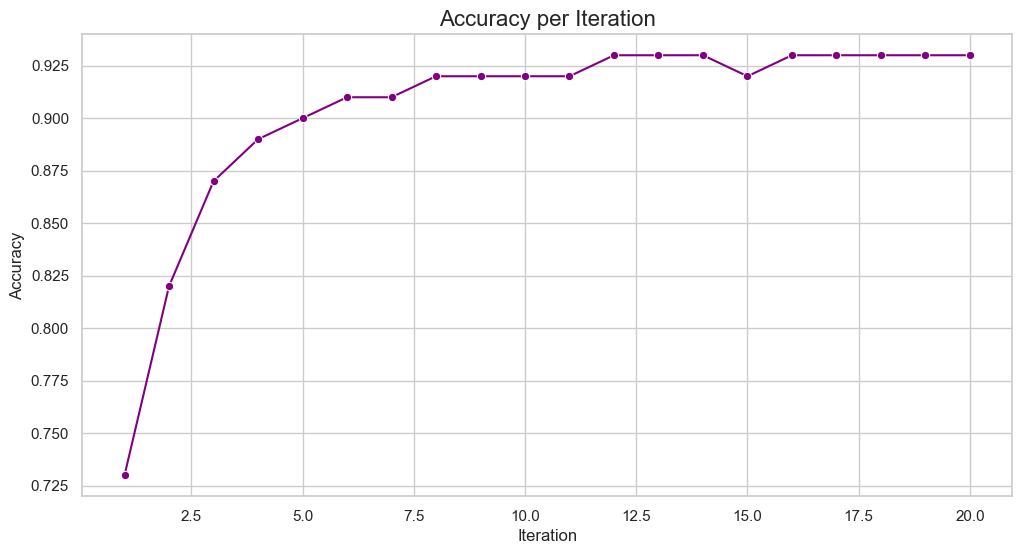

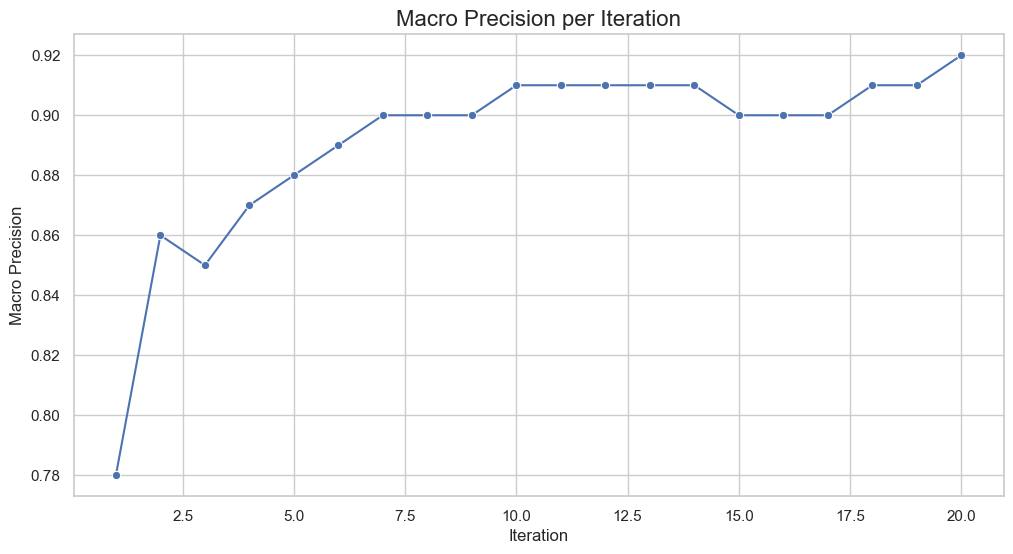

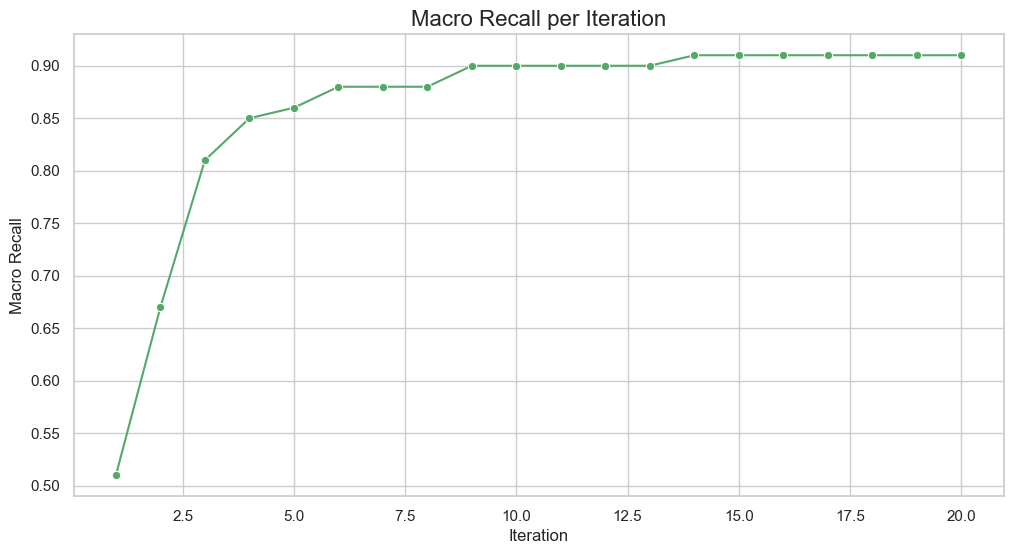

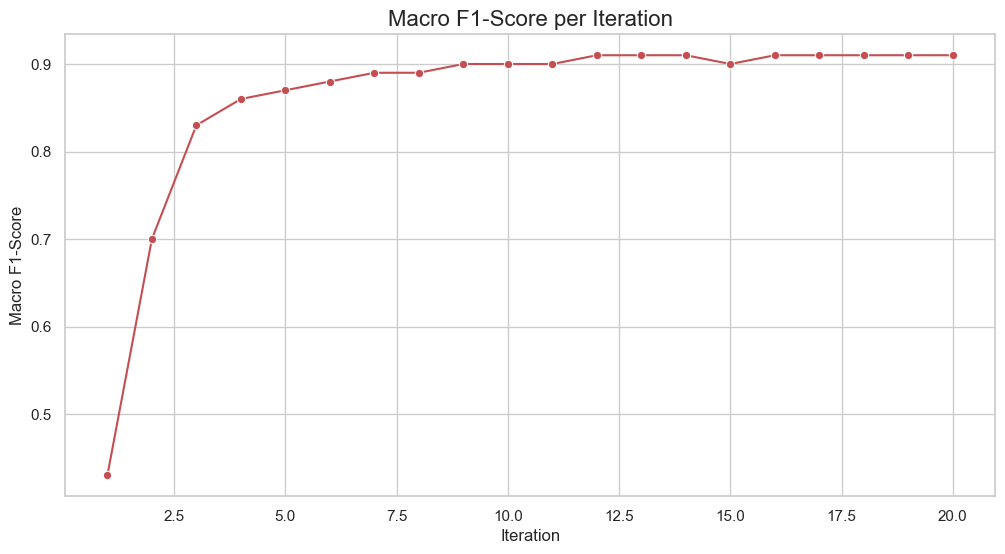

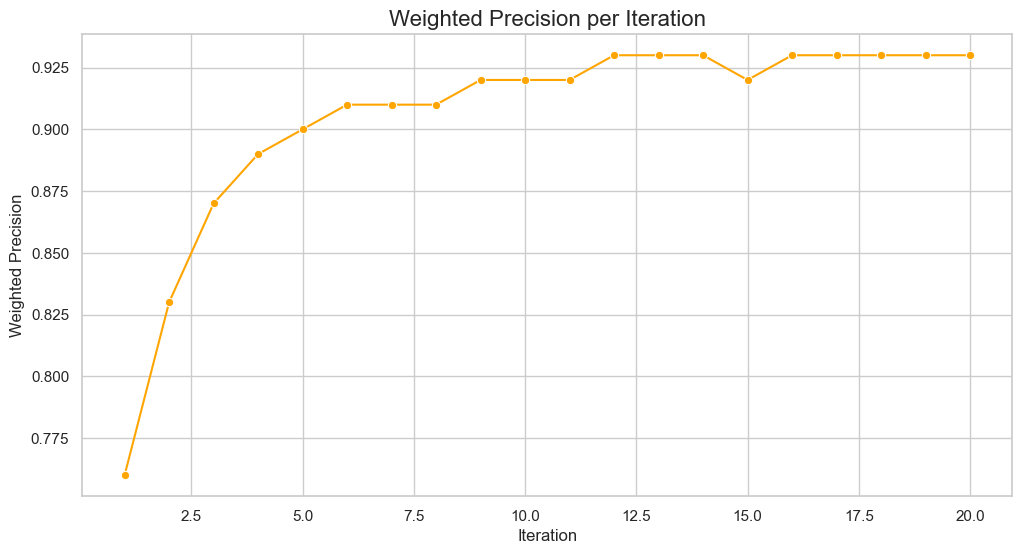

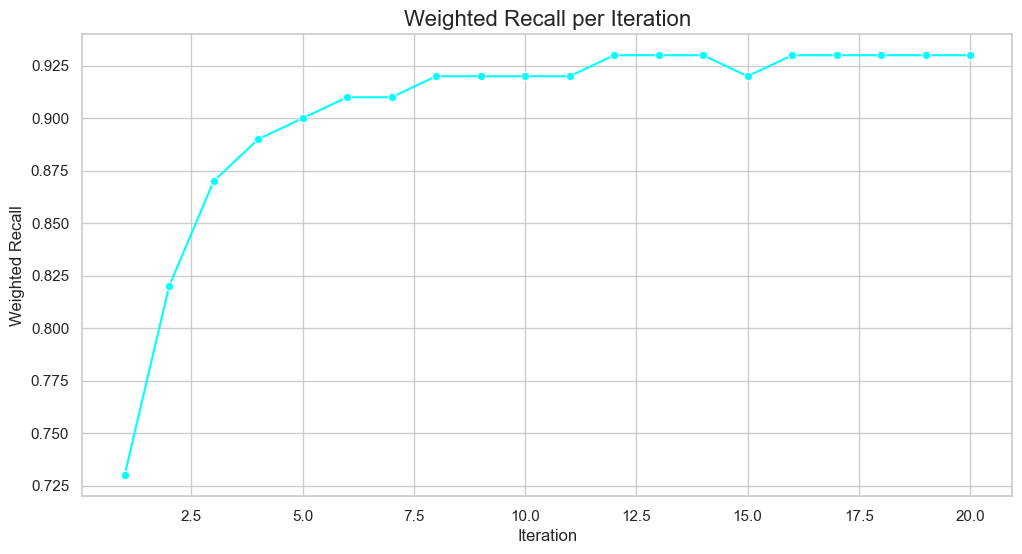

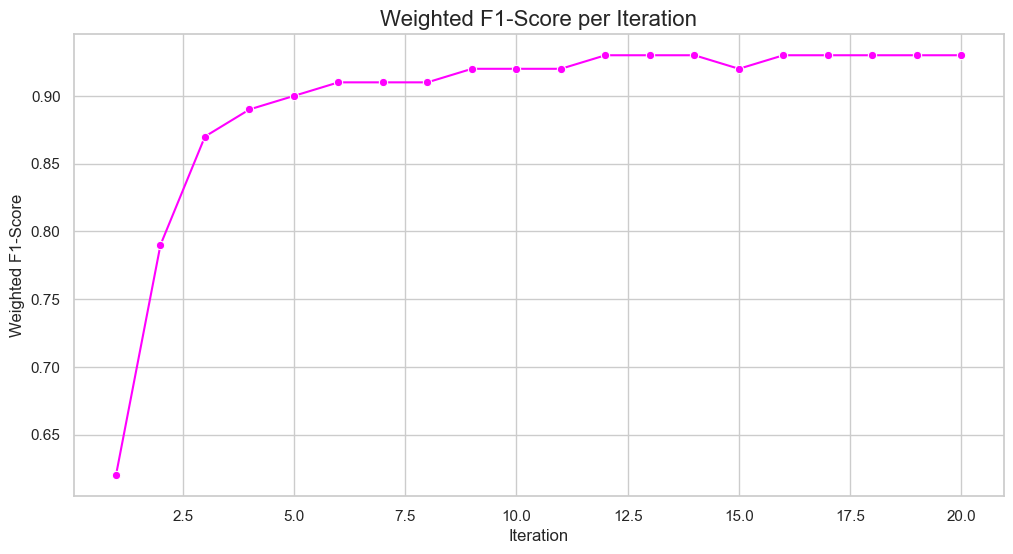

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假设文件名为result.txt
filename = 'result.txt'

# 读取数据
with open(filename, 'r') as file:
    data = file.readlines()

# 初始化列表
accuracy = []
macro_precision, macro_recall, macro_f1 = [], [], []
weighted_precision, weighted_recall, weighted_f1 = [], [], []

# 清洗数据
for line in data:
    if 'accuracy' in line:
        acc_value = float(line.split()[1])
        accuracy.append(acc_value)
    elif 'macro avg' in line:
        parts = line.split()
        macro_precision.append(float(parts[2]))
        macro_recall.append(float(parts[3]))
        macro_f1.append(float(parts[4]))
    elif 'weighted avg' in line:
        parts = line.split()
        weighted_precision.append(float(parts[2]))
        weighted_recall.append(float(parts[3]))
        weighted_f1.append(float(parts[4]))

# 创建DataFrame
df = pd.DataFrame({
    'Iteration': range(1, len(accuracy) + 1),
    'Accuracy': accuracy,
    'Macro Precision': macro_precision,
    'Macro Recall': macro_recall,
    'Macro F1-Score': macro_f1,
    'Weighted Precision': weighted_precision,
    'Weighted Recall': weighted_recall,
    'Weighted F1-Score': weighted_f1
})

# 设置金融科技风格
sns.set_theme(style="whitegrid")

# 可视化 Accuracy
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Iteration', y='Accuracy', marker='o', color="purple")
plt.title('Accuracy per Iteration', fontsize=16)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.savefig('accuracy_per_iteration.png')
plt.show()

# 可视化 Macro Precision
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Iteration', y='Macro Precision', marker='o', color="b")
plt.title('Macro Precision per Iteration', fontsize=16)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Macro Precision', fontsize=12)
plt.savefig('macro_precision_per_iteration.png')
plt.show()

# 可视化 Macro Recall
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Iteration', y='Macro Recall', marker='o', color="g")
plt.title('Macro Recall per Iteration', fontsize=16)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Macro Recall', fontsize=12)
plt.savefig('macro_recall_per_iteration.png')
plt.show()

# 可视化 Macro F1-Score
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Iteration', y='Macro F1-Score', marker='o', color="r")
plt.title('Macro F1-Score per Iteration', fontsize=16)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.savefig('macro_f1_score_per_iteration.png')
plt.show()

# 可视化 Weighted Precision
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Iteration', y='Weighted Precision', marker='o', color="orange")
plt.title('Weighted Precision per Iteration', fontsize=16)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Weighted Precision', fontsize=12)
plt.savefig('weighted_precision_per_iteration.png')
plt.show()

# 可视化 Weighted Recall
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Iteration', y='Weighted Recall', marker='o', color="cyan")
plt.title('Weighted Recall per Iteration', fontsize=16)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Weighted Recall', fontsize=12)
plt.savefig('weighted_recall_per_iteration.png')
plt.show()

# 可视化 Weighted F1-Score
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Iteration', y='Weighted F1-Score', marker='o', color="magenta")
plt.title('Weighted F1-Score per Iteration', fontsize=16)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Weighted F1-Score', fontsize=12)
plt.savefig('weighted_f1_score_per_iteration.png')
plt.show()


## 实例测试

In [3]:
import torch
import pandas as pd
from pytorch_pretrained_bert import BertTokenizer
import time
from concurrent.futures import ThreadPoolExecutor
from torch.utils.data import TensorDataset, DataLoader
start_time = time.time()  # 记录开始时间
device='cpu'
def predict_single_sentence(model, tokenizer, sentence, max_seq_len):
    # 处理单个句子
    data_test = pd.DataFrame({'id': [0], 'comment': [sentence], 'sentiment': [0]})
    processor = DataProcessForSingleSentence(bert_tokenizer=tokenizer)
    input_data = processor.get_input(data_test, max_seq_len)
    input_data = next(iter(input_data))
    # 将数据移动到相同的设备上，如 GPU
    input_data = tuple(t.unsqueeze(0).to(device) for t in input_data)
    # 推断
    model.eval()
    with torch.no_grad():
        logits = model(*input_data[:-1])
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()

    return predicted_class, probabilities.cpu().numpy()[0]
# 加载模型
loaded_model = torch.load('fine_tuned_chinese_bert_cpu.bin') 
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-chinese', do_lower_case=True)  
max_seq_len = 200
sentence = "海能达与非洲某国公共安全客户签订万美元项目合同"
predicted_class, probabilities = predict_single_sentence(loaded_model, bert_tokenizer, sentence, max_seq_len)
print("问题是：",sentence)
print(f"Predicted Class: {['消极的金融新闻','积极的金融新闻'][predicted_class]}, Probabilities: {probabilities[predicted_class]}")

end_time = time.time()  # 记录结束时间
execution_time = end_time - start_time  # 计算执行时间
print(f"Program executed in {execution_time} seconds")

问题是： 海能达与非洲某国公共安全客户签订万美元项目合同
Predicted Class: 积极的金融新闻, Probabilities: 0.9916090369224548
Program executed in 2.332000494003296 seconds
